# Customer Churn Prediction using Machine Learning (Random Forest Classifier)

This project predicts whether a customer will leave the bank (churn) or stay based on customer information such as geography, age, balance, credit score, and other factors.

The model used is **Random Forest Classifier**, a powerful ensemble machine learning algorithm for classification tasks.

## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Check Dataset File
First, we confirm that the dataset file exists in the notebook folder.

In [6]:
import os
print(os.listdir())

['.cache', '.copilot', '.dotnet', '.idlerc', '.ipynb_checkpoints', '.ipython', '.matplotlib', '.nuget', '.platformio', '.templateengine', '.vscode', '.vscode-shared', '2.0', '3D Objects', 'AppData', 'Application Data', 'Churn_Modelling.csv', 'citesmart', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'loan-prediction-dataset.csv', 'loan-prediction-dataset.ipynb', 'Local Settings', 'MicrosoftEdgeBackups', 'Music', 'My Documents', 'NetHood', 'New folder', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b7532662-0b6c-11f1-bcb4-caef04f235c2}.TM.blf', 'NTUSER.DAT{b7532662-0b6c-11f1-bcb4-caef04f235c2}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b7532662-0b6c-11f1-bcb4-caef04f235c2}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'source', 'Start Menu', 'Task 1 Iris Dataset.ipynb', 'Task 2.ipynb', 'Templates',

## Load Dataset

We load the churn dataset and inspect its structure.

In [7]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         938

## Dataset Overview

We check:
- Shape of dataset
- Columns
- First rows
- Missing values

In [8]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (10000, 14)

Columns:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00     

## Data Cleaning

We remove unnecessary columns:
- RowNumber
- CustomerId
- Surname

In [9]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

print("Columns after dropping unnecessary fields:")
print(df.columns)

Columns after dropping unnecessary fields:
Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')


## Encoding Categorical Data

We convert categorical columns into numerical format using one-hot encoding.

In [10]:
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

print("Dataset after encoding:")
print(df.head())

Dataset after encoding:
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   
2               0        113931.57       1              False   
3               0         93826.63       0              False   
4               1         79084.10       0              False   

   Geography_Spain  Gender_Male  
0            False        False  
1             True        False  
2            False        False  
3            False        False  
4     

## Exploratory Data Analysis (EDA)

### Age Distribution

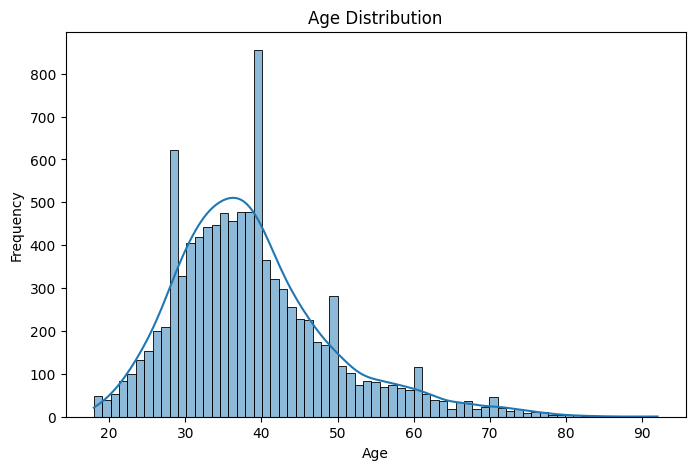

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Balance Distribution

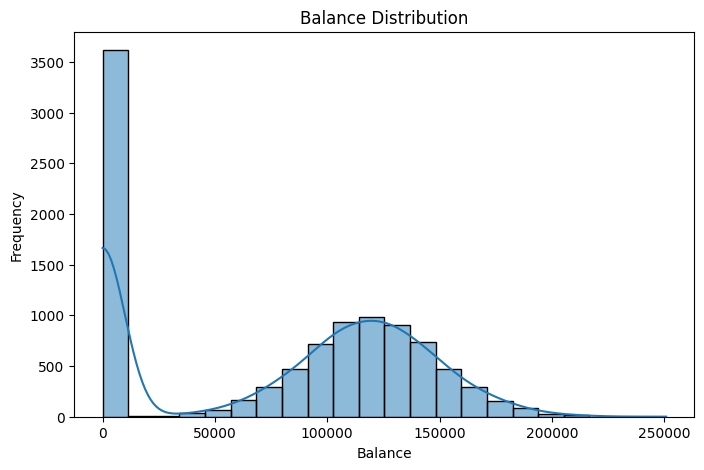

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Balance"], kde=True)

plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

### Churn Count

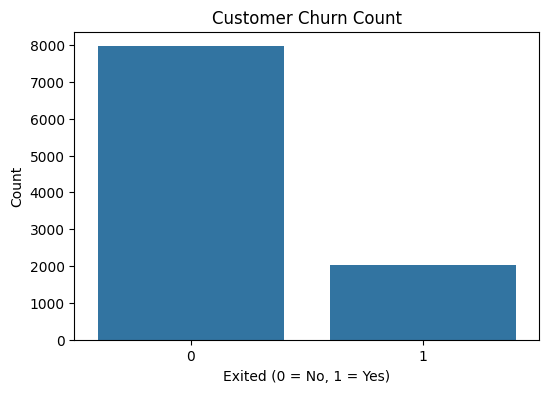

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Exited")

plt.title("Customer Churn Count")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

## Feature Selection

We separate features (X) and target variable (y).

In [17]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 11)
Target shape: (10000,)


## Train Test Split

Dataset is divided into:
- 80% Training Data
- 20% Testing Data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (8000, 11)
Testing data shape: (2000, 11)


## Random Forest Model Training

In [19]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Model Prediction

In [20]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


## Model Evaluation

We evaluate:
- Accuracy Score
- Confusion Matrix
- Classification Report

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8665

Confusion Matrix:
[[1548   59]
 [ 208  185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



## Confusion Matrix Visualization

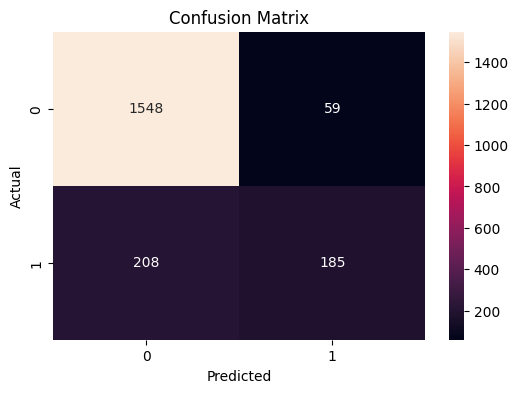

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

We identify which features most influence churn prediction.

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
              Feature  Importance
1                 Age    0.236922
7     EstimatedSalary    0.147558
0         CreditScore    0.143338
3             Balance    0.141612
4       NumOfProducts    0.131486
2              Tenure    0.082080
6      IsActiveMember    0.040725
8   Geography_Germany    0.026190
5           HasCrCard    0.018454
10        Gender_Male    0.018421
9     Geography_Spain    0.013214


## Feature Importance Visualization

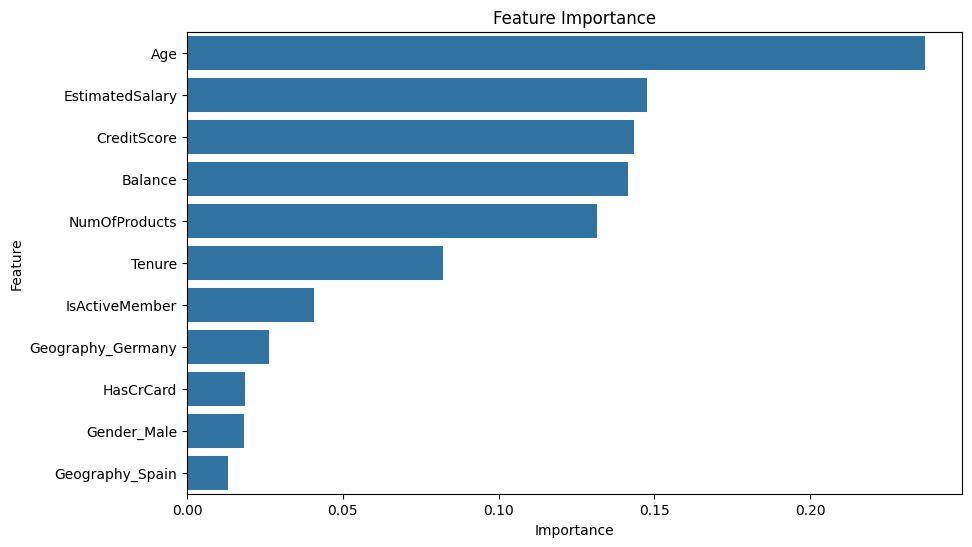

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Conclusion

In this project:

- Data was loaded and cleaned  
- Categorical data was encoded  
- Exploratory Data Analysis was performed  
- Random Forest Classifier was trained  
- Model accuracy was evaluated  
- Important churn factors were identified  

This project demonstrates a complete machine learning workflow for customer churn prediction.